In [36]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error, depolarizing_error
from scipy.optimize import minimize

In [37]:
np.random.seed(10)

In [38]:
num_qubits = 12
num_layers = 4

def create_sk_hamiltonian(num_qubits):
    coefs = []
    zz_terms = []
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            pauli_str = ['I'] * num_qubits
            pauli_str[i] = 'Z'
            pauli_str[j] = 'Z'
            
            coef = np.random.normal()/np.sqrt(num_qubits)
            
            coefs.append(coef)
            zz_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=coef))
            
    
    # X terms (transverse field)
    x_terms = []
    for i in range(num_qubits):
        pauli_str = ['I']*num_qubits
        pauli_str[i] = 'X'
        x_terms.append(SparsePauliOp(''.join(pauli_str), coeffs=1))
    
    return coefs, sum(zz_terms + x_terms)
    
coefs, hamiltonian = create_sk_hamiltonian(num_qubits)

In [39]:
coefs = coefs + [1.]*num_qubits

In [40]:
ansatz = TwoLocal(
    num_qubits,
    rotation_blocks='ry',
    entanglement_blocks='cx',
    entanglement='circular',
    reps=num_layers,
    skip_final_rotation_layer=True,
    insert_barriers=True
)

C:\Temp\ipykernel_22872\2045701409.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ansatz = TwoLocal(


In [41]:
lastnoiselesscost = None
noiselesshistory = []
def noiseless_cost(params):
    bound_circuit = ansatz.assign_parameters(params)
    
    transpiled = transpile(bound_circuit, backend_noiseless)
    transpiled.save_statevector()
    job = backend_noiseless.run(transpiled)
    result = job.result()
    statevector = result.get_statevector()
    
    cost = np.real(statevector.expectation_value(hamiltonian))
    lastnoiselesscost = cost
    return cost

def noiselesscallback(xk):
    # This is called after the iteration's line search is complete.
    # 'last_cost' now holds the cost at the accepted parameters xk.
    noiselesshistory.append(noiseless_cost(xk))

In [42]:
np.random.seed(30)
initial_params = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters)
backend_noiseless = AerSimulator(method='statevector')

In [43]:
%%time

result_noiseless = minimize(
    noiseless_cost,
    initial_params,
    callback=noiselesscallback,
    method='L-BFGS-B',
    options={'maxiter': 50}
)

CPU times: total: 3min 9s
Wall time: 3min 10s


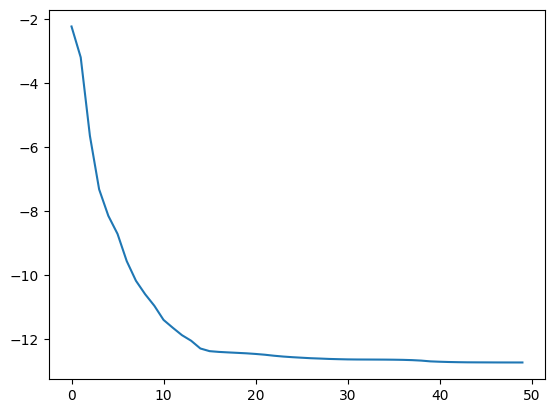

In [44]:
import matplotlib.pyplot as plt

plt.plot(noiselesshistory)

In [45]:
noiselesshistory[-1]

np.float64(-12.741676667773456)

In [46]:
backend_noiseless = AerSimulator(method='statevector')

two_qubit_error_rate = 0.01

noise_model = NoiseModel()

cnot_error = depolarizing_error(two_qubit_error_rate, 2)
noise_model.add_all_qubit_quantum_error(cnot_error, ['cx'])

backend_noisy = AerSimulator(noise_model=noise_model, method='density_matrix')

In [47]:
from qiskit.quantum_info import Statevector, Pauli, SparsePauliOp, StabilizerState, DensityMatrix

observables = []
for i in range(num_qubits):
    for j in range(i+1, num_qubits):
        pauli_str = ['I'] * num_qubits
        pauli_str[i] = 'Z'
        pauli_str[j] = 'Z'
        observables.append(Pauli(''.join(pauli_str)))
        
for i in range(num_qubits):
    pauli_str = ['I'] * num_qubits
    pauli_str[i] = 'X'
    observables.append(Pauli(''.join(pauli_str)))

import pandas as pd

df_near = pd.read_csv('./data/datasets/near_depolarization001.csv')
df_full = pd.read_csv('./data/datasets/depolarization001.csv')

num_terms = num_qubits*(num_qubits+1)//2

X_near = df_near[[f'noisy_{n}' for n in range(num_terms)]].values
y_near = df_near[[f'target_{n}' for n in range(num_terms)]].values

X_full = df_full[[f'noisy_{n}' for n in range(num_terms)]].values
y_full = df_full[[f'target_{n}' for n in range(num_terms)]].values

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipe_near = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", Ridge(alpha=0.1))
])
pipe_near.fit(X_near, y_near)

pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("linear", Ridge(alpha=0.1))
])
pipe_full.fit(X_full, y_full)

mitigated_cost_full_pipe_history = []
def mitigated_cost_full_pipe(params, history=False):
    bound_circuit = ansatz.assign_parameters(params)
    
    noisy_circuit = transpile(bound_circuit, backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix_data = result_noisy.data(0).get('density_matrix')
    dm = DensityMatrix(density_matrix_data)
    
    expectations = [np.array([np.real(dm.expectation_value(obs)) for obs in observables])]
    cost = sum(pipe_full.predict(expectations)[0]*coefs)
    if history:
        mitigated_cost_full_pipe_history.append(cost)
    return cost

mitigated_cost_near_pipe_history = []
def mitigated_cost_near_pipe(params, history=False):
    bound_circuit = ansatz.assign_parameters(params)
    
    noisy_circuit = transpile(bound_circuit, backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix_data = result_noisy.data(0).get('density_matrix')
    dm = DensityMatrix(density_matrix_data)
    
    expectations = [np.array([np.real(dm.expectation_value(obs)) for obs in observables])]
    cost = sum(pipe_near.predict(expectations)[0]*coefs)
    if history:
        mitigated_cost_near_pipe_history.append(cost)
    return cost

In [48]:
noisy_history = []
post_optim_full_history = []
post_optim_near_history = []
params_history = []
def noisy_cost(params):
    noisy_circuit = transpile(ansatz.assign_parameters(params), backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix = result_noisy.data()['density_matrix']
    noisy_energy = np.real(density_matrix.expectation_value(hamiltonian))
    return noisy_energy

def noisycallback(xk):
    # This is called after the iteration's line search is complete.
    # 'last_cost' now holds the cost at the accepted parameters xk.
    noisy_history.append(noisy_cost(xk))
    params_history.append(xk)

In [49]:
%%time

result_noisy = minimize(
    noisy_cost,
    initial_params,
    callback=noisycallback,
    method='L-BFGS-B',
    options={'maxiter': 50}
)

CPU times: total: 12h 39min 21s
Wall time: 1h 9min 43s


In [50]:
mitigated_cost_full_pipe(result_noisy.x)

np.float64(-13.018696152184402)

In [14]:
mitigated_cost_full_pipe_history = []
def mitigated_cost_full_pipe(params):
    bound_circuit = ansatz.assign_parameters(params)
    
    noisy_circuit = transpile(bound_circuit, backend_noisy)
    noisy_circuit.save_density_matrix()
    result_noisy = backend_noisy.run(noisy_circuit).result()
    density_matrix_data = result_noisy.data(0).get('density_matrix')
    dm = DensityMatrix(density_matrix_data)
    
    expectations = [np.array([np.real(dm.expectation_value(obs)) for obs in observables])]
    cost = sum(pipe_full.predict(expectations)[0]*coefs)
    return cost

def mitigback(xk):
    # This is called after the iteration's line search is complete.
    # 'last_cost' now holds the cost at the accepted parameters xk.
    mitigated_cost_full_pipe_history.append(mitigated_cost_full_pipe(xk))

In [58]:
%%time

result_mitigated_full_pipe = minimize(
    mitigated_cost_full_pipe,
    initial_params,
    callback=mitigback,
    method='L-BFGS-B',
    options={'maxiter': 50}
)

CPU times: total: 11h 42min 49s
Wall time: 1h 44s


In [54]:
post_optim_full_history = np.array([mitigated_cost_full_pipe(params) for params in params_history])

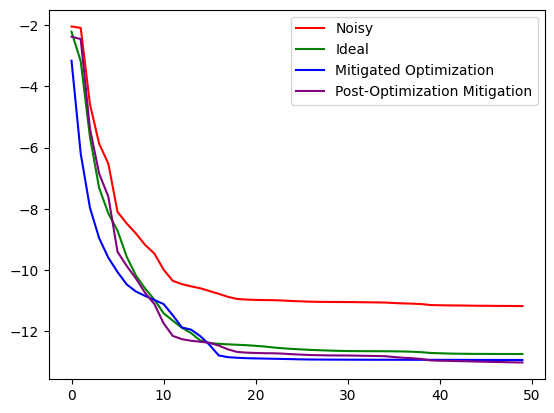

In [60]:
plt.plot(noisy_history, color='red', label='Noisy')
plt.plot(noiselesshistory, color='green', label='Ideal')
plt.plot(mitigated_cost_full_pipe_history, color='blue', label='Mitigated Optimization')
plt.plot(post_optim_full_history, color='purple', label='Post-Optimization Mitigation')
plt.legend()

In [61]:
np.save('noiseless_history.npy', noiselesshistory)

In [62]:
np.save('mitigated_cost_full_pipe_history.npy', mitigated_cost_full_pipe_history)

In [63]:
np.save('noisy_history.npy', noisy_history)

In [64]:
np.save('post_optim_full_history.npy', post_optim_full_history)

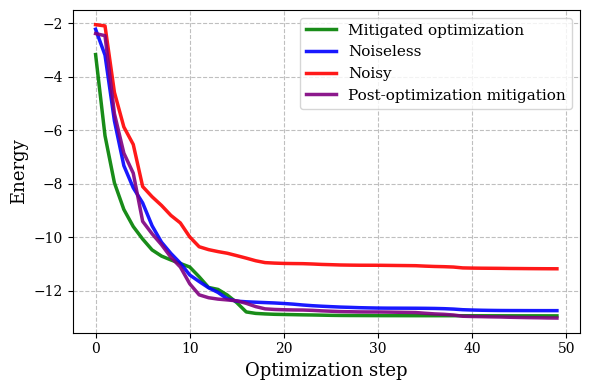

In [67]:
plt.figure(figsize=(6, 4), facecolor='w', edgecolor='k')
plt.rcParams.update({
    "font.family": "serif",               # use serif font (like LaTeX)
    "mathtext.fontset": "cm",              # Computer Modern for math
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "text.usetex": False                   # do not use external LaTeX
})

plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.8)
w = 2.5
plt.plot(mitigated_cost_full_pipe_history, color='green', label='Mitigated optimization', alpha=0.9, linewidth=w)
plt.plot(noiselesshistory, color='blue', label='Noiseless', alpha=0.9, linewidth=w)
plt.plot(noisy_history, color='red', label='Noisy', alpha=0.9, linewidth=w)
plt.plot(post_optim_full_history, color='purple', label = 'Post-optimization mitigation', alpha=0.9, linewidth=w)
plt.xlabel('Optimization step')
plt.ylabel('Energy')
plt.legend()
plt.tight_layout()
plt.savefig('optimization.pdf')